<a href="https://colab.research.google.com/github/mehdiiiii786/finance/blob/main/VOLATILITY_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [103]:
import pandas as pd
import numpy as np
import plotly.express as px
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import plotly.graph_objects as go


In [135]:
class stocksimulator :
  def __init__(self, ticker):
    self.ticker = ticker
    self.ticker_machine = yf.Ticker(ticker)
    sdata = self.ticker_machine.history(period = 'max')
    self.data = pd.DataFrame(sdata)
  def feature_engin(self):
    self.data['moving_average'] = self.data['Close'].rolling(window =  10).mean()
    self.data['daily return'] = self.data['Close'].pct_change()
    self.data['volatility'] = self.data['daily return'].rolling(window = 30).std() * np.sqrt(252)
    self.data = self.data.dropna()
    print(self.data)
  def normal_dist(self):
    x = self.data['volatility']
    fig, ax = plt.subplots()
    ax.hist(x, bins=8, linewidth=0.5, edgecolor="white")
    self.plot = plt.show()
    print(self.plot)
  def Target(self):
    dynamic_knife = self.data['volatility'].quantile(0.75)
    self.knife = dynamic_knife
    self.data['Regime'] = np.where(self.data['volatility'].shift(-1) > dynamic_knife, 1, 0)
    self.data = self.data.dropna()
    print(self.data)
    print("the dynamic knife is : " , self.knife)
  def Logistic_regression(self):
    X = self.data[['moving_average', 'daily return']]
    Y = self.data['Regime']
    model = LogisticRegression()
    self.model = model
    x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, shuffle = False)
    self.model.fit(x_train, y_train)
    todays_data = X.iloc[-1:]
    tomorrows_guess = self.model.predict(todays_data)
    if tomorrows_guess[0] == 1 :
      print("volatile")
    else :
      print("pas trés volatile")
  def plot_interactive_volatility(self):
    fig = go.Figure()

    # 1. Plot the Volatility Line
    fig.add_trace(go.Scatter(
        x=self.data.index,
        y=self.data['volatility'],
        mode='lines',
        name='30-Day Volatility',
        line=dict(color='blue')
    ))

    # 2. Draw the Dynamic Knife (Threshold)
    fig.add_hline(
        y=self.knife,
        line_dash="dash",
        line_color="red",
        annotation_text="Top 25% Crisis Threshold"
    )

    fig.update_layout(title=f"{self.ticker} Volatility Regime Tracker", template="plotly_dark")
    fig.show()
  def plot_crisis_zones(self):
    fig = go.Figure()

    # LAYER 1: The Base Price Line (Neutral Gray)
    # This connects all the days together so you can see the trend
    fig.add_trace(go.Scatter(
        x=self.data.index,
        y=self.data['Close'],
        mode='lines',
        line=dict(color='gray', width=1.5),
        name='Base Price',
        opacity=0.5 # We make it slightly faded so the colored dots pop!
    ))

    # LAYER 2: The Peacetime Dots (Green)
    # We slice out ONLY the rows where Regime is 0
    peace_data = self.data[self.data['Regime'] == 0]
    fig.add_trace(go.Scatter(
        x=peace_data.index,
        y=peace_data['Close'],
        mode='markers',
        marker=dict(color='#00ff00', size=4), # Hex code for neon green
        name='Peacetime (Regime 0)'
    ))

    # LAYER 3: The Crisis Dots (Red)
    # We slice out ONLY the rows where Regime is 1
    war_data = self.data[self.data['Regime'] == 1]
    fig.add_trace(go.Scatter(
        x=war_data.index,
        y=war_data['Close'],
        mode='markers',
        marker=dict(color='#ff0000', size=6), # Red, and slightly larger!
        name='Conflict (Regime 1)'
    ))

    # THE DASHBOARD AESTHETICS
    fig.update_layout(
        title=f"{self.ticker} Price Action vs. AI-Detected Crisis Regimes",
        xaxis_title="Date",
        yaxis_title="Closing Price ($)",
        template="plotly_dark", # Gives it that professional Bloomberg Terminal look
        hovermode="x unified" # Shows all data neatly when you hover your mouse
    )

    fig.show()


In [150]:

LMT = stocksimulator('WAR')

In [151]:
LMT.feature_engin()

                                Open       High        Low      Close  Volume  \
Date                                                                            
2025-02-14 00:00:00-05:00  17.897896  17.897896  17.800191  17.866808    1100   
2025-02-18 00:00:00-05:00  18.119954  18.333130  18.119954  18.251413    3900   
2025-02-19 00:00:00-05:00  18.159925  18.182131  18.155485  18.177691    2100   
2025-02-20 00:00:00-05:00  18.035572  18.035572  17.871250  18.022249    2100   
2025-02-21 00:00:00-05:00  17.862368  17.862368  17.672285  17.672285     700   
...                              ...        ...        ...        ...     ...   
2026-02-25 00:00:00-05:00  25.700001  25.870001  25.545000  25.745001    8900   
2026-02-26 00:00:00-05:00  25.760000  25.760000  25.180000  25.646999   29600   
2026-02-27 00:00:00-05:00  25.049999  25.049999  24.754999  25.020000   11900   
2026-03-02 00:00:00-05:00  25.090000  25.690001  24.900000  25.209999   70400   
2026-03-03 00:00:00-05:00  2

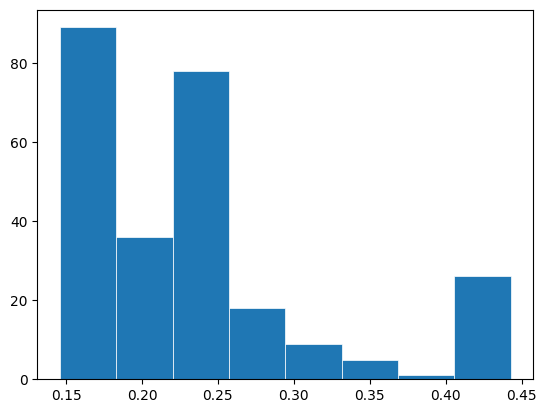

None


In [152]:
LMT.normal_dist()

In [153]:

LMT.Target()

                                Open       High        Low      Close  Volume  \
Date                                                                            
2025-02-14 00:00:00-05:00  17.897896  17.897896  17.800191  17.866808    1100   
2025-02-18 00:00:00-05:00  18.119954  18.333130  18.119954  18.251413    3900   
2025-02-19 00:00:00-05:00  18.159925  18.182131  18.155485  18.177691    2100   
2025-02-20 00:00:00-05:00  18.035572  18.035572  17.871250  18.022249    2100   
2025-02-21 00:00:00-05:00  17.862368  17.862368  17.672285  17.672285     700   
...                              ...        ...        ...        ...     ...   
2026-02-25 00:00:00-05:00  25.700001  25.870001  25.545000  25.745001    8900   
2026-02-26 00:00:00-05:00  25.760000  25.760000  25.180000  25.646999   29600   
2026-02-27 00:00:00-05:00  25.049999  25.049999  24.754999  25.020000   11900   
2026-03-02 00:00:00-05:00  25.090000  25.690001  24.900000  25.209999   70400   
2026-03-03 00:00:00-05:00  2

In [154]:
LMT.Logistic_regression()

pas trés volatile


In [155]:
LMT.plot_interactive_volatility()

In [156]:
LMT.plot_crisis_zones()